In [1]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms.v2 as transforms
import pandas as pd
import numpy as np
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
from torchvision.transforms.functional import to_pil_image
import math

In [2]:
def set_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)
# torch.backends.cuda.matmul.allow_tf32 = True
# torch.backends.cudnn.allow_tf32 = True
# torch.backends.cudnn.benchmark = True

set_seed(SEED)

# os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # wymagane przez niektóre operacje CUDA
device = torch.device("cuda")

In [3]:
base_transform = transforms.Compose(
    [
        transforms.ToImage(),
        transforms.ToDtype(torch.float32, scale=True),
    ])

In [4]:
full_trainset = torchvision.datasets.ImageFolder("trafic_32", transform=base_transform)

train_ratio = 0.8

targets = full_trainset.targets
indices = list(range(len(full_trainset)))

train_indices, val_indices = train_test_split(
    indices,
    train_size=train_ratio,
    stratify=targets,
    random_state=SEED
)

trainset = Subset(full_trainset, train_indices)
valset = Subset(full_trainset, val_indices)

num_classes = len(trainset.dataset.classes)

print(f"Number of classes: {num_classes}")
print(f"Trainset size: {len(trainset)}")
print(f"Validation set size: {len(valset)}")

Number of classes: 43
Trainset size: 31367
Validation set size: 7842


In [5]:
temp_transform = transforms.Compose(
    [
        transforms.Resize(32),
    ]
)

In [6]:
# all_samples = torch.stack([temp_transform(sample[0]) for sample in trainset])
# mean = all_samples.mean(axis=(0,2,3))
# std=all_samples.std(axis=(0,2,3))
# print(f"Data norm per channel: mean={mean} | std={std}")
# all_samples = None

In [7]:
mean = torch.tensor([0.3186, 0.2932, 0.3018])
std = torch.tensor([0.2762, 0.2654, 0.2686])

In [8]:
class WrappedSubset:
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        self.classes = subset.dataset.classes
        self.targets = [subset.dataset.targets[i] for i in subset.indices]

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

In [9]:
train_transform = transforms.Compose(
    [
        transforms.Resize(32),
        transforms.Normalize(mean=mean, std=std),
    ]
)

test_transform = transforms.Compose(
    [
        transforms.Resize(32),
        transforms.Normalize(mean=mean, std=std),
    ]
)

trainset = WrappedSubset(trainset, transform=train_transform)
valset = WrappedSubset(valset, transform=test_transform)

In [10]:
batch_size = 128
shuffle = True
num_workers = 0
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=shuffle,
    num_workers=num_workers,
    pin_memory=True,
    drop_last=True,
    )
valloader = torch.utils.data.DataLoader(
    valset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    )

In [11]:
# # dane bezpośrednio na GPU
# all_x = []
# all_y = []
# for x, y in trainset:
#     all_x.append(x)
#     all_y.append(y)

# tensor_x = torch.stack(all_x).to(device)
# tensor_y = torch.tensor(all_y, dtype=torch.int64).to(device) 

# gpu_dataset = torch.utils.data.TensorDataset(tensor_x, tensor_y)

# trainloader = torch.utils.data.DataLoader(
#     gpu_dataset,
#     batch_size=batch_size,
#     shuffle=True, 
#     drop_last=True
# )

In [12]:

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class ResBlock(nn.Module):
    """Residual block with GroupNorm and FiLM conditioning (No Attention)."""
    def __init__(self, in_channels, out_channels, emb_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        
        self.norm2 = nn.GroupNorm(8, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        
        # Projection for FiLM: produces scale and shift for every output channel
        self.emb_proj = nn.Linear(emb_dim, out_channels * 2)
        
        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x, emb):
        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)
        
        # FiLM modulation
        emb_out = self.emb_proj(F.silu(emb))[:, :, None, None]
        scale, shift = torch.chunk(emb_out, 2, dim=1)
        h = h * (1.0 + scale) + shift
        
        h = self.norm2(h)
        h = F.silu(h)
        h = self.conv2(h)
        
        return h + self.shortcut(x)

class ImprovedUNet(nn.Module):
    def __init__(self, num_classes, in_channels=3, out_channels=3, emb_dim=256):
        super().__init__()
        
        # Plus one embedding for no class
        self.class_emb = nn.Embedding(num_classes + 1, emb_dim)
        self.time_emb = SinusoidalPositionEmbeddings(emb_dim)
        
        self.emb_mlp = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim)
        )
        
        self.init_conv = nn.Conv2d(in_channels, 64, kernel_size=3, padding=1)
        
        # Encoder (Downsampling)
        self.down1 = ResBlock(64, 128, emb_dim)             # 32x32
        self.down2 = ResBlock(128, 256, emb_dim)            # 16x16
        # self.down3 = ResBlock(256, 512, emb_dim)            # 8x8
        
        # Bottleneck: 3 ResBlocks for deep abstraction (replacing Attention)
        self.mid_block1 = ResBlock(256, 256, emb_dim)
        self.mid_block_extra = ResBlock(256, 256, emb_dim)
        self.mid_block2 = ResBlock(256, 256, emb_dim)
        
        # Decoder (Upsampling)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.pool = nn.MaxPool2d(2)
        
        # self.up3 = ResBlock(512 + 256, 256, emb_dim)        # 16x16
        self.up2 = ResBlock(256 + 128, 128, emb_dim)        # 32x32
        self.up1 = ResBlock(128 + 64, 64, emb_dim)          # 32x32
        
        self.out_norm = nn.GroupNorm(8, 64)
        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=3, padding=1)

    def forward(self, x, t, y):
        t_emb = self.time_emb(t)
        y_emb = self.class_emb(y)
        emb = self.emb_mlp(t_emb + y_emb)
        
        x0 = self.init_conv(x)
        
        # Encoder
        x1 = self.down1(x0, emb)
        x1_pool = self.pool(x1)
        
        x2 = self.down2(x1_pool, emb)
        # x2_pool = self.pool(x2)
        
        # x3 = self.down3(x2_pool, emb)
        
        # Bottleneck 
        m = self.mid_block1(x2, emb)
        m = self.mid_block_extra(m, emb)
        m = self.mid_block2(m, emb)
        
        # Decoder
        # u3 = self.upsample(m)
        # u3 = torch.cat([u3, x2], dim=1) # Skip connection from x2
        # u3 = self.up3(u3, emb)
        
        u2 = self.upsample(m)
        u2 = torch.cat([u2, x1], dim=1) # Skip connection from x1
        u2 = self.up2(u2, emb)
        
        u1 = torch.cat([u2, x0], dim=1) # Skip connection from x0
        u1 = self.up1(u1, emb)
        
        out = self.out_norm(u1)
        out = F.silu(out)
        return self.out_conv(out)

In [13]:
def corrupt(x, amount):
    """Corrupt the input `x` by mixing it with noise according to `amount`"""
    noise = torch.randn_like(x)
    amount = amount.view(-1, 1, 1, 1) # Sort shape so broadcasting works
    return x*(1-amount) + noise*amount

In [ ]:
net = ImprovedUNet(num_classes=num_classes).to(device)
# net = net.to(memory_format=torch.channels_last)
# net = torch.compile(net)
loss_fn = nn.MSELoss()

max_lr = 2e-3
# opt = torch.optim.AdamW(net.parameters(), lr=max_lr, weight_decay=1e-4, fused=True)
opt = torch.optim.AdamW(net.parameters(), lr=max_lr, weight_decay=1e-4)

n_epochs = 50
total_steps = n_epochs * len(trainloader)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    opt,
    max_lr=max_lr,
    total_steps=total_steps,
    pct_start=0.1,      # Spend the first 10% of steps warming up
    anneal_strategy='cos' # Cosine decay for the remaining 90%
)

losses = []

for epoch in range(n_epochs):
    for x, y in trainloader:
        opt.zero_grad(set_to_none=True)

        # x = x.to(device, memory_format=torch.channels_last)
        x = x.to(device)
        y = y.to(device)

        # Classifier-Free Guidance mask (drop label 10% of the time)
        uncond_mask = torch.rand(y.shape[0], device=device) < 0.1
        y_train = y.clone()
        y_train[uncond_mask] = num_classes

        noise_amount = torch.rand(x.shape[0], device=device)
        noisy_x = corrupt(x, noise_amount)

        # with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        pred = net(noisy_x, noise_amount, y_train)
        loss = loss_fn(pred, x)

        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
        
        opt.step()
        scheduler.step()

        losses.append(loss.item())

    current_lr = scheduler.get_last_lr()[0]
    avg_loss = sum(losses[-len(trainloader):]) / len(trainloader)
    print(f'Epoch {epoch+1}/{n_epochs} | Loss: {avg_loss:.5f} | LR: {current_lr:.6f}')

In [18]:
# # loading
PATH = "lightnet6.8.pth"

net = ImprovedUNet(num_classes=num_classes)
net.load_state_dict(torch.load(PATH, map_location=device))
net.to(device)
net.eval()

ImprovedUNet(
  (class_emb): Embedding(44, 256)
  (time_emb): SinusoidalPositionEmbeddings()
  (emb_mlp): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): SiLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
  (init_conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (down1): ResBlock(
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 128, eps=1e-05, affine=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (emb_proj): Linear(in_features=256, out_features=256, bias=True)
    (shortcut): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
  )
  (down2): ResBlock(
    (norm1): GroupNorm(8, 128, eps=1e-05, affine=True)
    (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 256, eps=1e-05, affine=True)
    (conv2): Co

In [ ]:
# saving
# PATH = "lightnet6.8.pth"
#
# torch.save(net.state_dict(), PATH)
# print(f"Model weights saved to {PATH}")

Model weights saved to lightnet6.8.pth


In [ ]:
def generate_image_batch(net, class_labels, n_steps=40, cfg_weight=1.5):
    """
    Generates a batch of images and returns them as a [B, 3, 32, 32] tensor in [0, 1] range.
    
    Args:
        net: The trained ImprovedUNet model.
        class_labels: A 1D tensor of target class indices (shape: [batch_size]).
        n_steps: Number of denoising steps (fewer is faster).
        cfg_weight: How strongly to follow the class label (higher is sharper).
    """
    batch_size = class_labels.shape[0]
    device = next(net.parameters()).device
    
    # 1. Start with pure Gaussian noise
    x = torch.randn(batch_size, 3, 32, 32).to(device)
    
    # 2. Prepare labels for Classifier-Free Guidance
    # num_classes is used as the 'unconditional' token index
    y_uncond = torch.full((batch_size,), num_classes, dtype=torch.long, device=device)

    net.eval()
    for i in range(n_steps):
        t_val = (n_steps - i) / n_steps
        t = torch.full((batch_size,), t_val, device=device)

        with torch.no_grad():
            # Run both conditional and unconditional paths in one batch for speed
            x_double = torch.cat([x, x], dim=0)
            t_double = torch.cat([t, t], dim=0)
            y_double = torch.cat([class_labels, y_uncond], dim=0)
            
            # Get model predictions
            pred_double = net(x_double, t_double, y_double)
            pred_cond, pred_uncond = torch.chunk(pred_double, 2, dim=0)
            
            # Apply Classifier-Free Guidance formula:
            # Result = Unconditional + Weight * (Conditional - Unconditional)
            pred = pred_uncond + cfg_weight * (pred_cond - pred_uncond)
            std_cond = pred_cond.std(dim=(1, 2, 3), keepdim=True)
            std_guided = pred.std(dim=(1, 2, 3), keepdim=True)

            pred_rescaled = pred * (std_cond / std_guided)
            rescale_factor = 0.7  # Common value in research
            pred = rescale_factor * pred_rescaled + (1 - rescale_factor) * pred

        # Update the image: take a small step toward the prediction
        mix_factor = 1.0 / (n_steps - i)
        x = x * (1 - mix_factor) + pred * mix_factor

    # 3. Denormalize back to [0, 1] for FID calculation
    # Using the 'mean' and 'std' defined in your notebook
    mean_tensor = mean.view(1, 3, 1, 1).to(device)
    std_tensor = std.view(1, 3, 1, 1).to(device)
    
    x_denorm = (x * std_tensor) + mean_tensor
    return x_denorm.clip(0, 1)

In [20]:
def show_images(images):
    images = images.detach().cpu()
    n_samples = images.shape[0]

    nrow = 8
    grid = torchvision.utils.make_grid(images, nrow=nrow).clip(0, 1)

    img = to_pil_image(grid)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(np.asarray(img))
    plt.axis('off')
    plt.title(f'Generated Images')
    plt.tight_layout()
    # plt.savefig('improved_generation.png')
    plt.show()

In [21]:
def generate_and_show_images(net, class_label, n_steps=40, n_samples=64, cfg_weight=3.0):
    device = next(net.parameters()).device
    class_labels = torch.full((n_samples,), class_label, dtype=torch.long, device=device)
    images = generate_image_batch(
        net=net,
        class_labels=class_labels,
        n_steps=n_steps,
        cfg_weight=cfg_weight,
        )
    show_images(images=images)

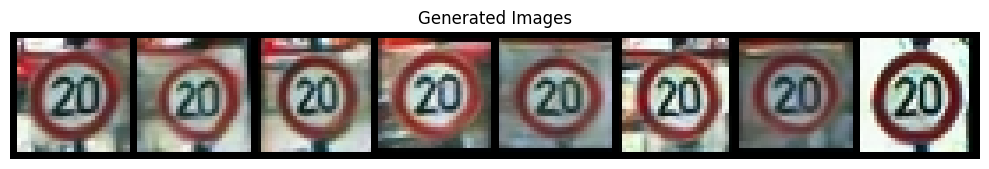

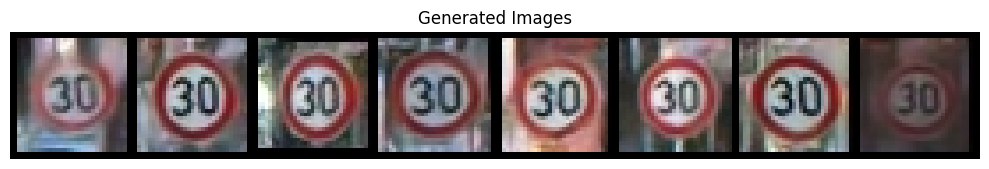

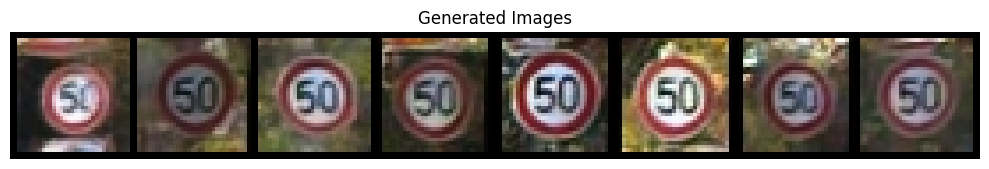

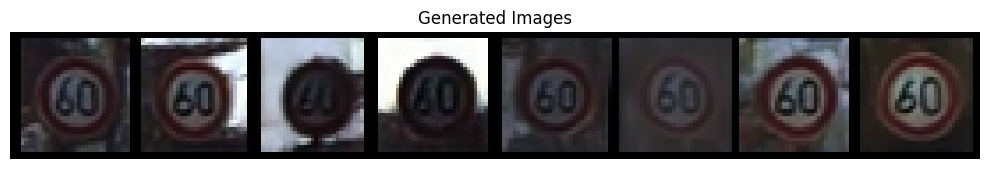

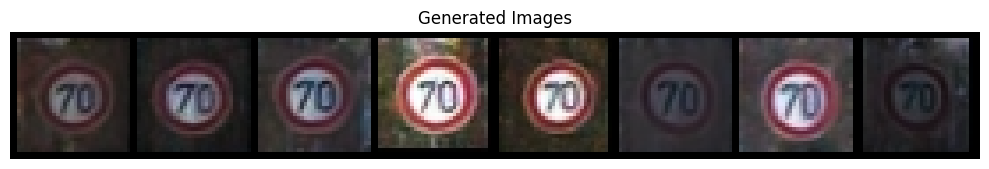

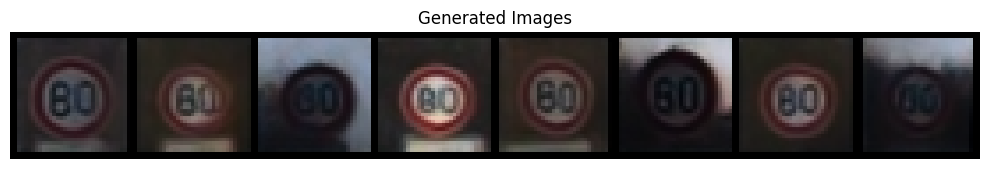

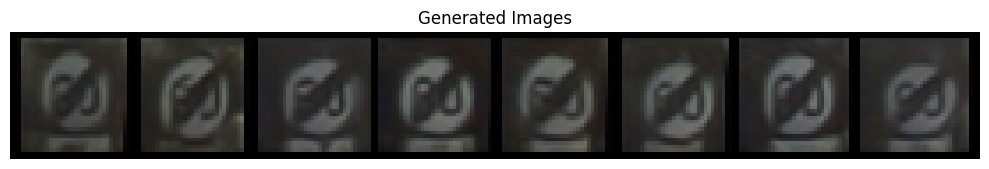

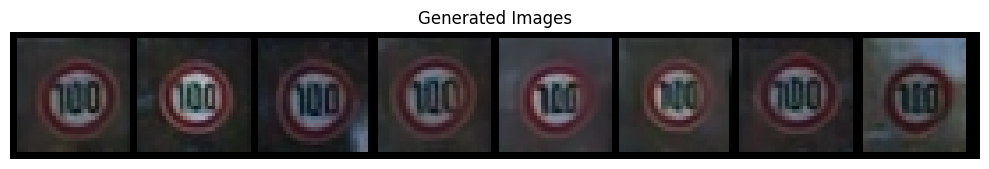

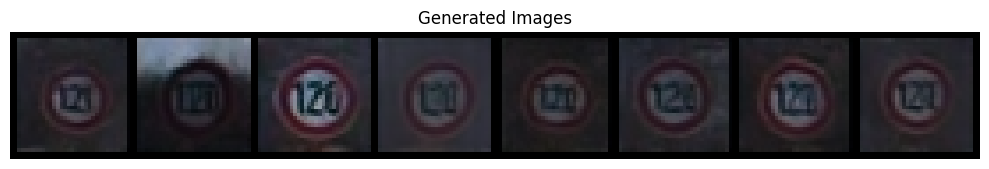

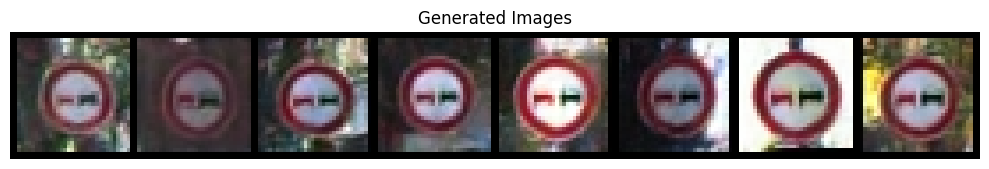

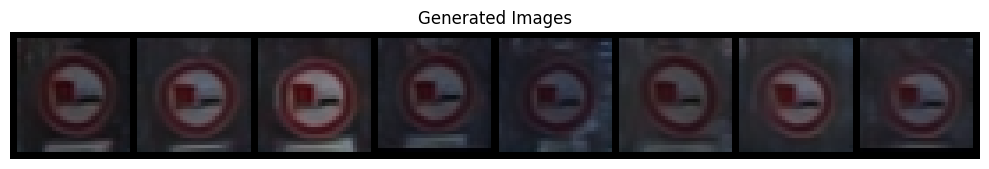

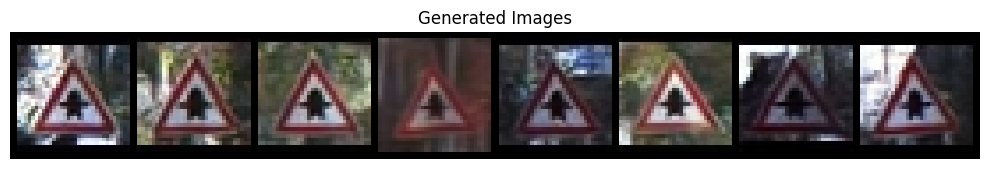

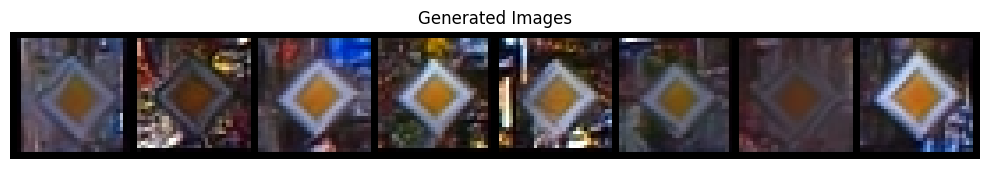

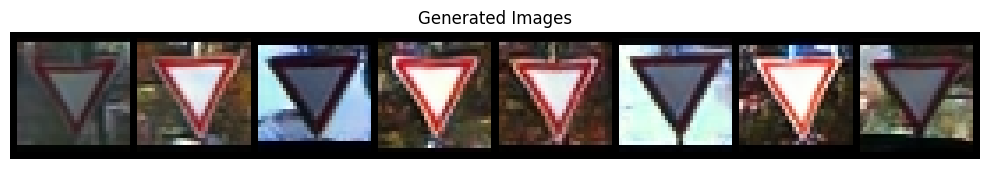

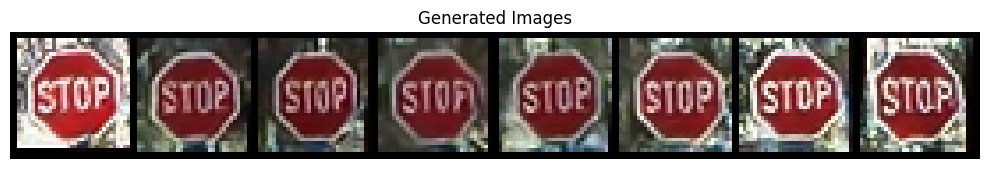

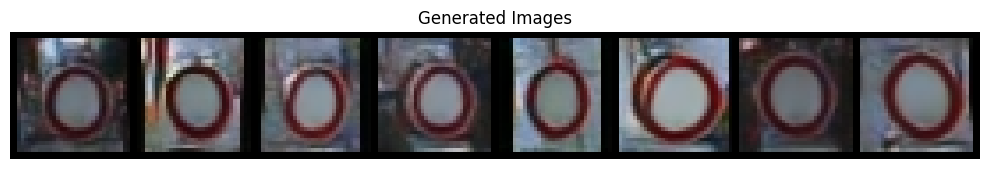

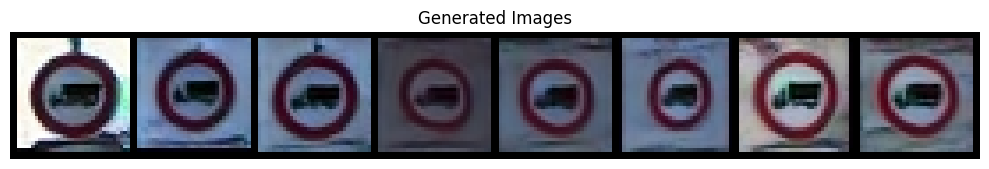

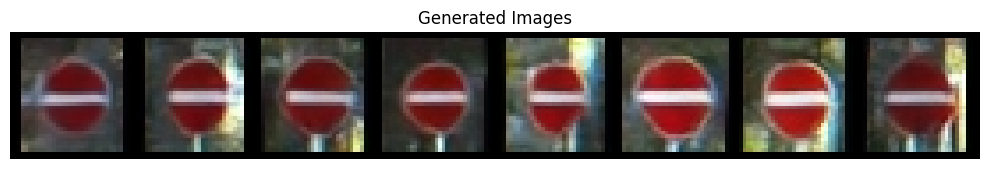

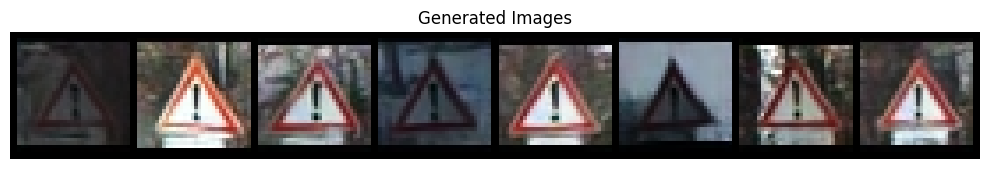

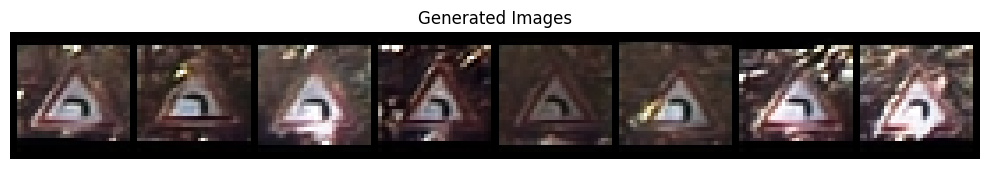

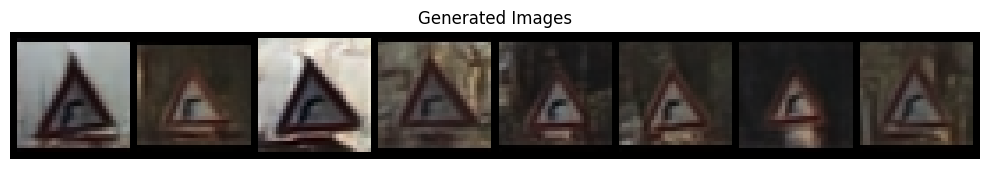

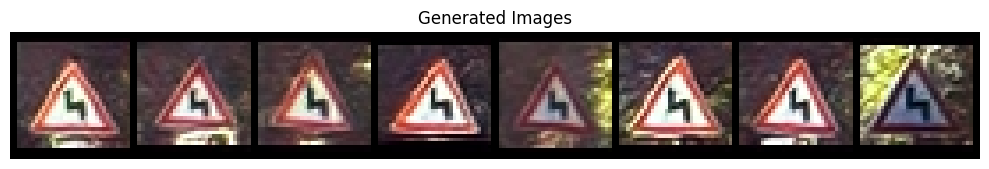

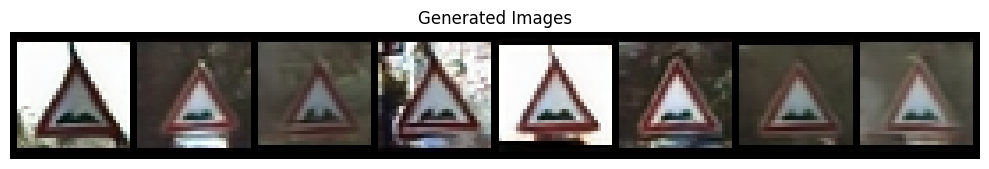

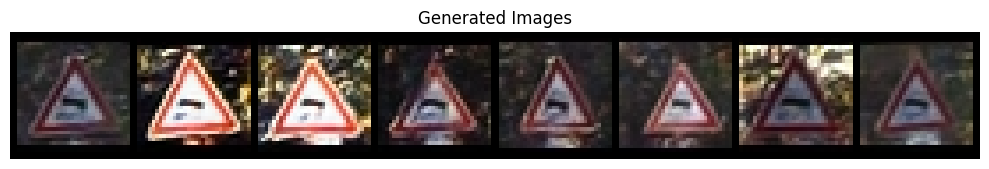

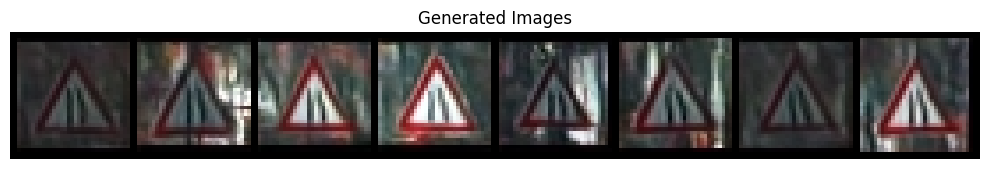

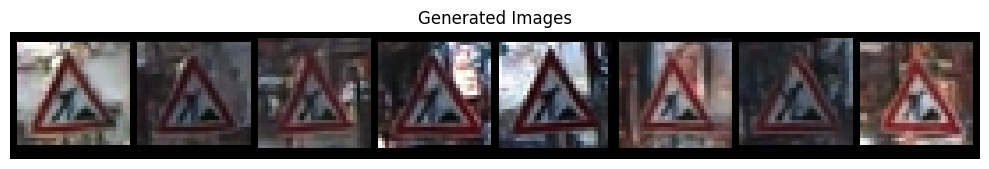

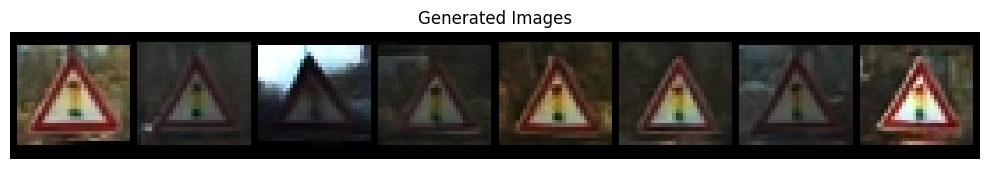

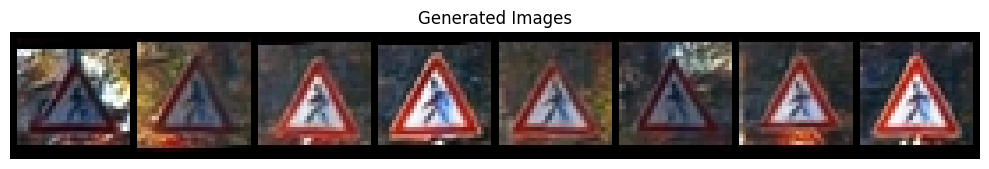

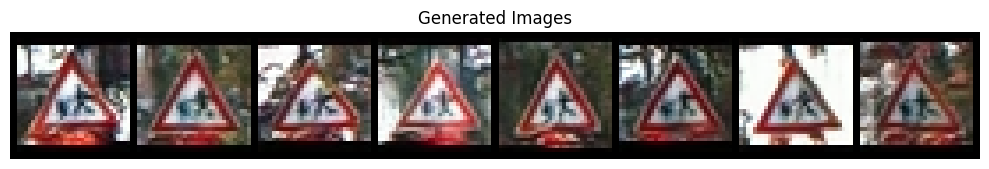

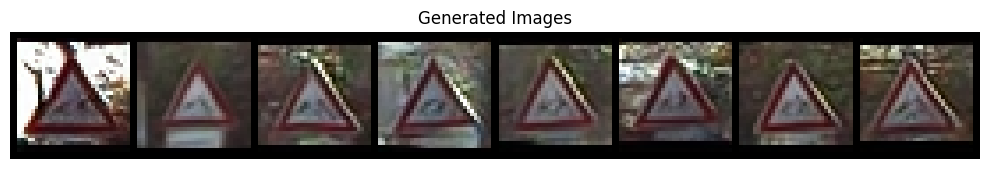

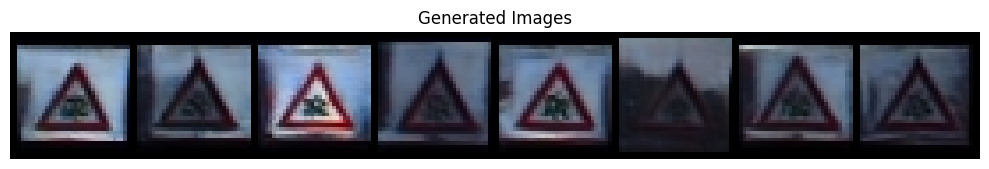

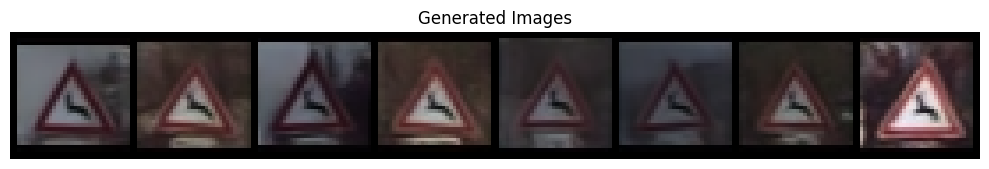

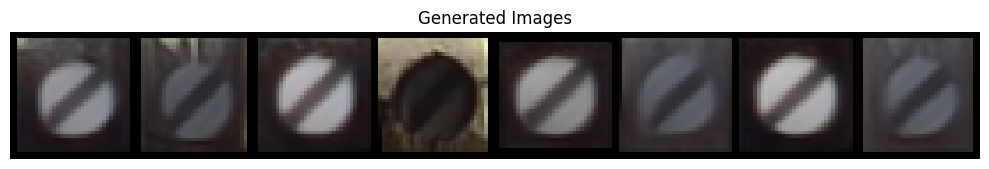

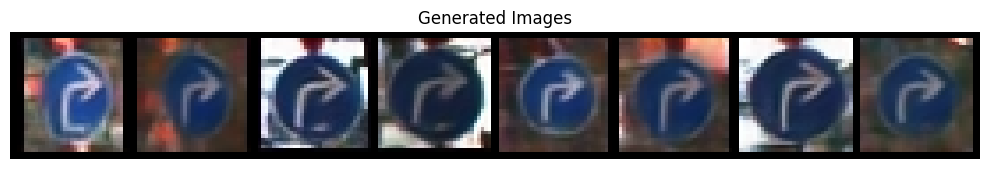

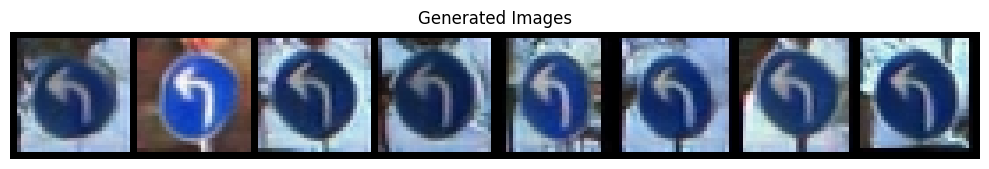

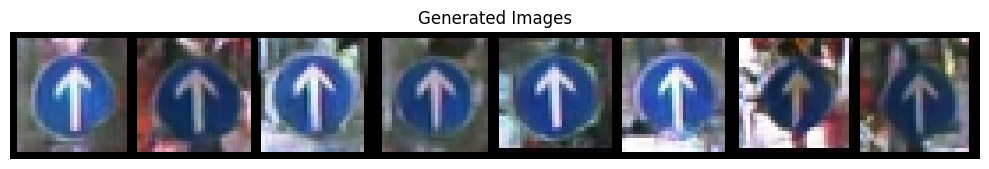

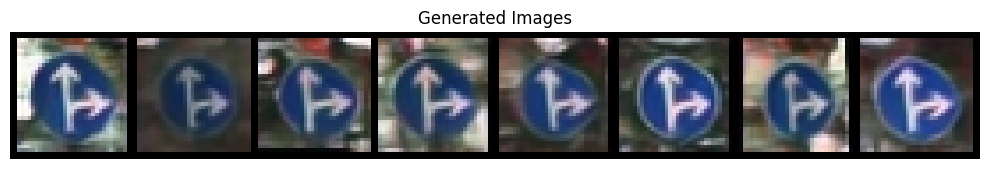

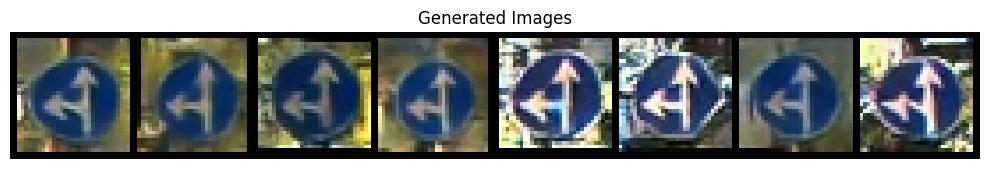

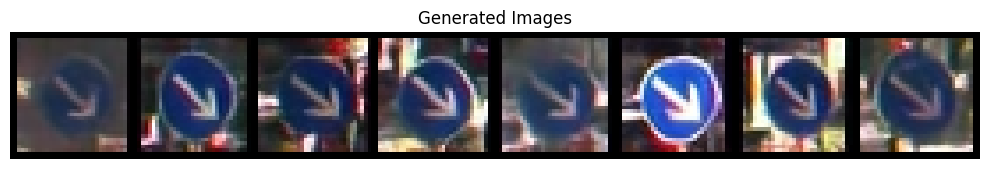

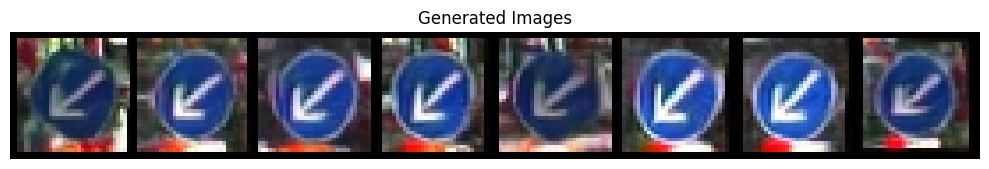

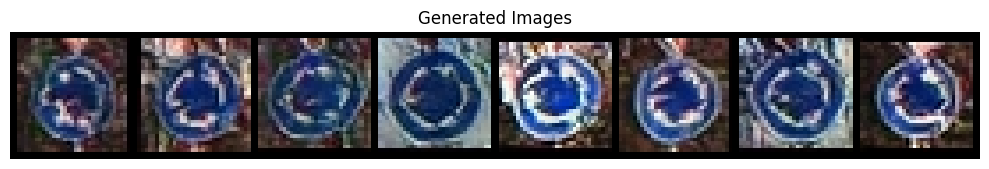

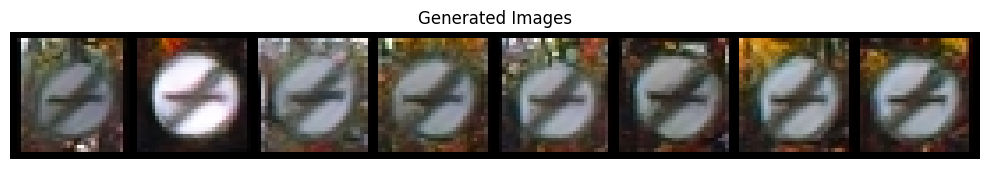

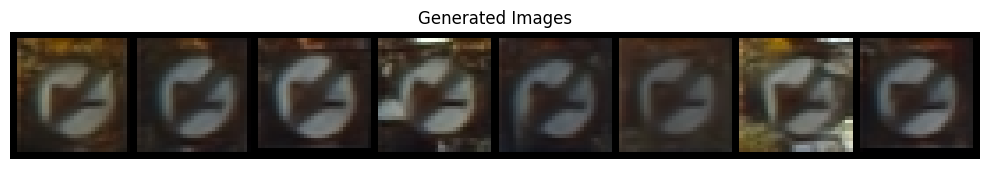

In [22]:
for class_label in range(num_classes):
    generate_and_show_images(net, class_label, n_samples=8)

In [23]:
class_weights = torch.zeros(num_classes)
for i in range(len(trainset)):
    class_weights[ trainset[i][1] ] += 1 

In [24]:
######### Frechet Inception distance based on implementation from https://github.com/mseitzer/pytorch-fid

from scipy import linalg


def calculate_frechet_distance(distribution_1, distribution_2, eps=1e-6):
    mu1 = np.mean(distribution_1, axis=0)
    sigma1 = np.cov(distribution_1, rowvar=False)

    mu2 = np.mean(distribution_2, axis=0)
    sigma2 = np.cov(distribution_2, rowvar=False)

    """Numpy implementation of the Frechet Distance.
    The Frechet distance between two multivariate Gaussians X_1 ~ N(mu_1, C_1)
    and X_2 ~ N(mu_2, C_2) is
            d^2 = ||mu_1 - mu_2||^2 + Tr(C_1 + C_2 - 2*sqrt(C_1*C_2)).
    Stable version by Dougal J. Sutherland.
    Params:
    -- mu1   : Numpy array containing the activations of a layer of the
               inception net (like returned by the function 'get_predictions')
               for generated samples.
    -- mu2   : The sample mean over activations, precalculated on an
               representative data set.
    -- sigma1: The covariance matrix over activations for generated samples.
    -- sigma2: The covariance matrix over activations, precalculated on an
               representative data set.
    Returns:
    --   : The Frechet Distance.
    """

    mu1 = np.atleast_1d(mu1)
    mu2 = np.atleast_1d(mu2)

    sigma1 = np.atleast_2d(sigma1)
    sigma2 = np.atleast_2d(sigma2)

    assert mu1.shape == mu2.shape, \
        'Training and test mean vectors have different lengths'
    assert sigma1.shape == sigma2.shape, \
        'Training and test covariances have different dimensions'

    diff = mu1 - mu2

    # Product might be almost singular
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if not np.isfinite(covmean).all():
        msg = ('fid calculation produces singular product; '
               'adding %s to diagonal of cov estimates') % eps
        print(msg)
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = linalg.sqrtm((sigma1 + offset).dot(sigma2 + offset))

    # Numerical error might give slight imaginary component
    if np.iscomplexobj(covmean):
        if not np.allclose(np.diagonal(covmean).imag, 0, atol=1e-3):
            m = np.max(np.abs(covmean.imag))
            raise ValueError('Imaginary component {}'.format(m))
        covmean = covmean.real

    tr_covmean = np.trace(covmean)

    return (diff.dot(diff) + np.trace(sigma1) +
            np.trace(sigma2) - 2 * tr_covmean)

In [ ]:
from torchvision.models import inception_v3, Inception_V3_Weights

def extract_inception_features_from_tensors(tensor_batches, inception_model, device):
    """
    Takes a list or generator of tensor batches (B, 3, H, W) in [0, 1] range,
    resizes them to 299x299, applies ImageNet normalization, and extracts 2048-d features.
    """
    inception_model.eval()
    activations = []
    
    # Standard ImageNet normalization required by InceptionV3
    norm_mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
    norm_std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

    with torch.no_grad():
        for batch in tensor_batches:
            batch = batch.to(device)
            
            # 1. Resize 32x32 to 299x299 instantly on GPU
            batch_resized = F.interpolate(batch, size=(299, 299), mode='bilinear', align_corners=False)
            
            # 2. Normalize to standard ImageNet distribution
            batch_normalized = (batch_resized - norm_mean) / norm_std
            
            # 3. Extract features
            pred = inception_model(batch_normalized)
            pred = pred.squeeze(-1).squeeze(-1) # (B, 2048)
            activations.append(pred.cpu().numpy())
            
    return np.concatenate(activations, axis=0)


def evaluate_fid(net, valloader, num_eval_samples=1000, batch_size=128, cfg_weight=1.5):
    print(f"Initializing In-Memory FID Evaluation ({num_eval_samples} samples)...")
    
    # Load Inception model directly to GPU
    inception = inception_v3(weights=Inception_V3_Weights.DEFAULT)
    inception.fc = torch.nn.Identity() # Strip classification head
    inception = inception.to(device)
    
    # --- A. Process Real Images from existing valloader ---
    print("Extracting features from Validation Set...")
    real_batches = []
    samples_collected = 0
    
    # Pre-calculated dataset norms from your notebook to denorm back to [0, 1]
    mean_tensor = mean.view(1, 3, 1, 1).to(device)
    std_tensor = std.view(1, 3, 1, 1).to(device)

    for x, _ in valloader:
        x = x.to(device)
        # Denormalize your specific dataset preprocessing back to raw [0, 1] images
        x_denorm = (x * std_tensor) + mean_tensor
        real_batches.append(x_denorm.clip(0, 1))
        
        samples_collected += x.shape[0]
        if samples_collected >= num_eval_samples:
            break
            
    real_features = extract_inception_features_from_tensors(real_batches, inception, device)
    real_features = real_features[:num_eval_samples] # Trim exact amount

    # --- B. Process Generated Images on-the-fly ---
    print("Generating and extracting features for Synthetic Images...")
    gen_batches = []
    samples_generated = 0
    
    while samples_generated < num_eval_samples:
        current_batch_size = min(batch_size, num_eval_samples - samples_generated)
        
        # Pick random classes matching your distribution
        random_classes = torch.multinomial(class_weights, num_samples=current_batch_size, replacement=True).to(device)
        
        # Generate batch (ensure your generate function returns denormalized [0,1] tensors)
        # Assuming generate_improved_images is modified to accept specific labels and batch size without plotting
        gen_tensor = generate_image_batch(net, random_classes, cfg_weight=cfg_weight)
        
        gen_batches.append(gen_tensor)
        samples_generated += current_batch_size
        
    gen_features = extract_inception_features_from_tensors(gen_batches, inception, device)

    # --- C. Compute FID ---
    print("Computing Fréchet Distance...")
    fid_score = calculate_frechet_distance(real_features, gen_features)
    print(f"\n---> In-Memory FID Score: {fid_score:.4f} <---")
    
    # Clean up GPU memory
    del inception
    torch.cuda.empty_cache()
    
    return fid_score

In [26]:
import os

def export_generated_dataset_to_image_files(net, output_dir="generated_dataset", total_images=5000, batch_size=128):
    """Generates synthetic images and saves them into appropriate class folders."""
    os.makedirs(output_dir, exist_ok=True)
    
    # Create subdirectories for all 43 classes
    for c in range(num_classes):
        os.makedirs(os.path.join(output_dir, f"class_{c:02d}"), exist_ok=True)
        
    images_saved = 0
    net.eval()
    
    print(f"Exporting {total_images} images to '{output_dir}'...")
    
    while images_saved < total_images:
        current_b = min(batch_size, total_images - images_saved)
        
        # Generate a batch of random classes
        labels = torch.multinomial(class_weights, num_samples=current_b, replacement=True).to(device)
        
        # Generate raw tensors in [0, 1] range
        generated_tensors = generate_image_batch(net, labels)
        
        # Save each image individually into its respective class folder
        for i in range(current_b):
            c_label = labels[i].item()
            img_tensor = generated_tensors[i]
            
            file_path = os.path.join(output_dir, f"class_{c_label:02d}", f"img_{images_saved:06d}.png")
            torchvision.utils.save_image(img_tensor, file_path)
            images_saved += 1
            
        if images_saved % 500 == 0:
            print(f"Saved {images_saved}/{total_images} images...")
            
    print("Dataset export complete!")

In [ ]:
def export_generated_dataset_to_torch_tensor(net,  filename, total_images=1000, batch_size=128, cfg_weight=1.5):
    net.eval()
    images_generated = 0
    generated = []
    while images_generated < total_images:
        current_b = min(batch_size, total_images - images_generated)
        labels = torch.multinomial(class_weights, num_samples=current_b, replacement=True).to(device)
        generated_batch = generate_image_batch(net, labels, cfg_weight=cfg_weight)
        generated.append(generated_batch.cpu().detach())
        images_generated += current_b
        print(f"generated {images_generated}/{total_images}")
        
    generated_imgs = torch.concat(generated, dim=0)
    torch.save(generated_imgs.cpu().detach(),filename)

In [ ]:
scores = []
for cfg in [1.0, 1.5, 2.0, 3.0, 4.0]:
    print(f"Evaluating FID with CFG weight {cfg}...")
    fid_score = evaluate_fid(net, valloader, num_eval_samples=1000, batch_size=128, cfg_weight=cfg)
    scores.append(fid_score)

print("\nFinal FID Scores for different CFG weights:")
for cfg, score in zip([1.0, 1.5, 2.0, 3.0, 4.0], scores):
    print(f"CFG Weight {cfg}: FID = {score:.4f}")

Evaluating FID with CFG weight 1.0...
Initializing In-Memory FID Evaluation (1000 samples)...
Extracting features from Validation Set...
Generating and extracting features for Synthetic Images...
Computing Fréchet Distance...


/tmp/ipykernel_33501/120805413.py:45: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)



---> In-Memory FID Score: 39.8384 <---
Evaluating FID with CFG weight 1.5...
Initializing In-Memory FID Evaluation (1000 samples)...
Extracting features from Validation Set...
Generating and extracting features for Synthetic Images...
Computing Fréchet Distance...

---> In-Memory FID Score: 36.5886 <---
Evaluating FID with CFG weight 2.0...
Initializing In-Memory FID Evaluation (1000 samples)...
Extracting features from Validation Set...
Generating and extracting features for Synthetic Images...
Computing Fréchet Distance...

---> In-Memory FID Score: 37.0688 <---
Evaluating FID with CFG weight 3.0...
Initializing In-Memory FID Evaluation (1000 samples)...
Extracting features from Validation Set...
Generating and extracting features for Synthetic Images...
Computing Fréchet Distance...

---> In-Memory FID Score: 43.1273 <---
Evaluating FID with CFG weight 4.0...
Initializing In-Memory FID Evaluation (1000 samples)...
Extracting features from Validation Set...
Generating and extracting

In [30]:
export_generated_dataset_to_torch_tensor(net, "sroda_BoteroLeonikSebastian_JedrychAdrian.pt", cfg_weight=1.5)

generated 128/1000
generated 256/1000
generated 384/1000
generated 512/1000
generated 640/1000
generated 768/1000
generated 896/1000
generated 1000/1000
